# **Assignment 02: Object Detection**

**Available:** Aug 26, 2025 until Sep 4, 2025 11:59pm

## Tasks:

1. Object Detection- refer to slides 8/26/2025 class
2. https://www.kaggle.com/datasets/awsaf49/coco-2017-dataset
3. Run detection performance comparing (inference only):
    - Faster R-CNN
    - DETR
    - DINO
    - Grounding DINO (use text prompt at your discretion)
4. Grading Criteria:
    - Report
    - Code
    - Video
    - Insight


## **Import Packages and Setup**

In [1]:
## Import Libraries

# Set CUDA_VISIBLE_DEVICES to make both GPUs visible
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

# Install all packages for from the requirements.txt
%pip install -r requirements.txt

import torch
import torch.nn as nn
import torchvision
import cv2
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch import optim
from tqdm.notebook import tqdm
from torchinfo import summary
import einops
import PIL
import numpy as np
import pandas as pd
# Use a pipeline as a high-level helper
from transformers import pipeline

# Authorize Huggingface account
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv('/mnt/Storage02/SoftwareDev/CAP_6411_Assignments/.env')

# Get Hugging Face token
hf_token = os.getenv('HUGGINGFACE_HUB_TOKEN') or os.getenv('HF_TOKEN')

if hf_token:
    print("Found Hugging Face token in environment variables")
    
    
    from huggingface_hub import login, whoami
    
    try:
        # Login to Hugging Face Hub
        login(token=hf_token)
        
        # Verify login by getting user info
        user_info = whoami()
        print(f"Successfully authenticated with Hugging Face!")
        print(f"Logged in as: {user_info['name']}")
        
        # Set the token as environment variable for other libraries
        os.environ['HUGGINGFACE_HUB_TOKEN'] = hf_token
        os.environ['HF_TOKEN'] = hf_token
        
    except Exception as e:
        print(f"Authentication failed: {e}")
        print("Will proceed without pre-trained models if needed")
        hf_token = None
else:
    print("No Hugging Face token found in .env file")
    print("Please add HUGGINGFACE_HUB_TOKEN=your_token_here to your .env file")
    hf_token = None

# Comprehensive GPU diagnostics
print("\n=== GPU Diagnostics ===")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs detected: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print("\n=== All Available GPUs ===")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}:")
        print(f"  Name: {props.name}")
        print(f"  Total Memory: {props.total_memory / 1024**3:.2f} GB")
        print(f"  Multi-processor count: {props.multi_processor_count}")
        print(f"  Compute Capability: {props.major}.{props.minor}")
        print()

# Device selection with preference for cuda:1 (A6000) -> cuda:0 (4090) -> cpu
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    device = torch.device('cuda:1')  # This should now be your A6000!
    print(f"Using GPU 1: {torch.cuda.get_device_name(1)}")
elif torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f"Using GPU 0: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("Using CPU")

print(f"Selected device: {device}")

# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")

  Using cached torch-2.8.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (30 kB)
  Using cached torchvision-0.23.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached torchaudio-2.8.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (7.2 kB)
  Using cached timm-1.0.19-py3-none-any.whl.metadata (60 kB)
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached pandas-2.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (91 kB)
  Using cached matplotlib-3.10.6-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached opencv_python-4.12.0.88-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (19 kB)
  Using cached pillow-11.3.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.0 kB)
  Using cached pycocotools-2.0.10-cp310-cp310-manylinux_2_17_x86_64.manylinux2

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Successfully authenticated with Hugging Face!
Logged in as: malneyugnfl

=== GPU Diagnostics ===
PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA version: 12.8
Number of GPUs detected: 1

=== All Available GPUs ===
GPU 0:
  Name: NVIDIA GeForce RTX 4090 Laptop GPU
  Total Memory: 15.70 GB
  Multi-processor count: 76
  Compute Capability: 8.9

Using GPU 0: NVIDIA GeForce RTX 4090 Laptop GPU
Selected device: cuda:0


## **Import and Process Data**

In [2]:
# Import Dataset and Process it

import json
from PIL import Image
from torch.utils.data import Dataset
import os

class CocoDataset(Dataset):
    """
    Custom PyTorch Dataset class for loading COCO 2017 data.
    
    This class handles loading images and their corresponding annotations from the COCO dataset,
    making it compatible with PyTorch DataLoaders and various object detection models.
    """
    
    def __init__(self, root_dir, split="val2017", annotation_type="instances", transform=None, return_coco=False):
        """
        Initialize the COCO dataset.
        
        Args:
            root_dir (str): Path to the COCO dataset root directory (should contain 'annotations', 'train2017', 'val2017', etc.)
            split (str): Dataset split - one of 'train2017', 'val2017', or 'test2017'
            annotation_type (str): Type of annotations - 'instances', 'captions', or 'person_keypoints'
            transform (callable, optional): Transform to apply to images and targets
            return_coco (bool): If True, also return the raw COCO annotation dict for each sample
        """
        # Store initialization parameters
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.return_coco = return_coco
        
        # Set up image directory path
        self.img_dir = os.path.join(root_dir, split)
        self.annotation_type = annotation_type
        
        # Handle test split (which has no annotations)
        if split == "test2017":
            self.annotations = None
            # For test set, just get list of image filenames
            self.imgs = sorted(os.listdir(self.img_dir))
        else:
            # Load annotation file for train/val splits
            ann_file = os.path.join(
                root_dir, "annotations", f"{annotation_type}_{split}.json"
            )
            
            # Load COCO annotations JSON file
            with open(ann_file, "r") as f:
                self.coco = json.load(f)
            
            # Extract images and annotations from COCO data
            self.imgs = self.coco["images"]  # List of image metadata
            self.anns = self.coco["annotations"]  # List of annotation objects
            
            # Create mapping from image_id to list of annotations for that image
            # This allows fast lookup of annotations for a given image
            self.imgid_to_anns = {}
            for ann in self.anns:
                img_id = ann["image_id"]
                if img_id not in self.imgid_to_anns:
                    self.imgid_to_anns[img_id] = []
                self.imgid_to_anns[img_id].append(ann)
            
            # Create mapping from image_id to filename for easy access
            self.imgid_to_filename = {img["id"]: img["file_name"] for img in self.imgs}
            
            # Create mapping from category_id to category name (useful for visualization)
            self.catid_to_name = {cat["id"]: cat["name"] for cat in self.coco.get("categories", [])}

    def __len__(self):
        """Return the total number of images in the dataset."""
        return len(self.imgs)

    def __getitem__(self, idx):
        """
        Get a single sample from the dataset.
        
        Args:
            idx (int): Index of the sample to retrieve
            
        Returns:
            tuple: (image, target) where:
                - image: PIL Image or transformed tensor
                - target: Dictionary containing bounding boxes, labels, and other metadata
        """
        
        # Handle test split (no annotations available)
        if self.split == "test2017":
            img_name = self.imgs[idx]
            img_path = os.path.join(self.img_dir, img_name)
            image = Image.open(img_path).convert("RGB")
            target = {}  # Empty target for test images
        else:
            # Get image metadata and construct path
            img_info = self.imgs[idx]
            img_id = img_info["id"]
            img_name = img_info["file_name"]
            img_path = os.path.join(self.img_dir, img_name)
            
            # Load image and convert to RGB
            image = Image.open(img_path).convert("RGB")
            
            # Get all annotations for this image
            anns = self.imgid_to_anns.get(img_id, [])
            
            # Extract bounding box and label information from annotations
            boxes = []      # Bounding boxes in [x, y, width, height] format
            labels = []     # Category IDs for each object
            areas = []      # Area of each bounding box
            iscrowd = []    # Whether each annotation represents a crowd of objects
            
            for ann in anns:
                # Only process annotations that have bounding boxes
                if "bbox" in ann:
                    boxes.append(ann["bbox"])  # COCO format: [x, y, width, height]
                    labels.append(ann["category_id"])
                    areas.append(ann.get("area", 0))
                    iscrowd.append(ann.get("iscrowd", 0))
            
            # Create target dictionary in PyTorch format
            # Convert lists to tensors, handling empty cases
            target = {
                "boxes": torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0,4), dtype=torch.float32),
                "labels": torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
                "image_id": torch.tensor([img_id]),  # Unique identifier for this image
                "area": torch.tensor(areas, dtype=torch.float32) if areas else torch.zeros((0,), dtype=torch.float32),
                "iscrowd": torch.tensor(iscrowd, dtype=torch.int64) if iscrowd else torch.zeros((0,), dtype=torch.int64),
            }
        
        # Apply transforms if provided (e.g., normalization, resizing)
        if self.transform:
            image = self.transform(image)
        
        # Optionally return raw COCO annotations along with processed data
        if self.return_coco and self.split != "test2017":
            return image, target, anns
        
        return image, target

# Example usage:
# Create a dataset instance
# dataset = CocoDataset(
#     root_dir="data/coco2017",              # Path to COCO dataset
#     split="val2017",                       # Use validation split
#     annotation_type="instances",           # Object detection annotations
#     transform=transforms.ToTensor(),       # Convert PIL Images to tensors
# )
# 
# # Get a single sample
# img, target = dataset[0]
# print(f"Image shape: {img.shape}")
# print(f"Number of objects: {len(target['labels'])}")
# print(f"Object categories: {target['labels']}")
# print(f"Bounding boxes: {target['boxes']}")
#
# # Use with DataLoader for batching
# from torch.utils.data import DataLoader
# dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
# for batch_imgs, batch_targets in dataloader:
#     # Process batch
#     break

In [4]:
# Create Instance of dataset for inference

# Define transforms for inference (normalize to match model expectations)
inference_transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL Image to tensor and scale to [0,1]
    # Note: Different models may need different normalization
    # We'll apply model-specific transforms during inference
])

# Create dataset instance pointing to the COCO 2017 validation set
coco_dataset = CocoDataset(
    root_dir="data/coco2017",           # Path to COCO dataset
    split="val2017",                    # Use validation split for inference
    annotation_type="instances",        # Object detection annotations
    transform=inference_transform,      # Apply transforms
    return_coco=False                   # Don't need raw COCO annotations for inference
)

print(f"Dataset loaded successfully!")
print(f"Number of images in validation set: {len(coco_dataset)}")
print(f"Available categories: {len(coco_dataset.catid_to_name)} classes")

# Define a proper collate function that can be pickled
def collate_fn(batch):
    """
    Custom collate function for object detection.
    Since we're using batch_size=1, this just returns the batch as-is.
    """
    return batch

# Create DataLoader for batched inference
# Using batch_size=1 for inference to avoid complications with variable-sized images
inference_dataloader = DataLoader(
    coco_dataset,
    batch_size=1,                       # Process one image at a time
    shuffle=False,                      # No need to shuffle for inference
    num_workers=0,                      # Set to 0 to avoid pickling issues with custom classes
    collate_fn=collate_fn,             # Use proper function instead of lambda
    pin_memory=True if torch.cuda.is_available() else False  # Speed up GPU transfer
)

print(f"DataLoader created with batch size: {inference_dataloader.batch_size}")
print(f"Number of batches: {len(inference_dataloader)}")

# Test loading a single sample to verify everything works
print("\n=== Testing dataset loading ===")
try:
    sample_image, sample_target = coco_dataset[0]
    print(f"Sample loaded successfully!")
    print(f"Image shape: {sample_image.shape}")
    print(f"Image dtype: {sample_image.dtype}")
    print(f"Number of objects in image: {len(sample_target['labels'])}")
    print(f"Object categories in image: {sample_target['labels'].tolist()}")
    print(f"Image ID: {sample_target['image_id'].item()}")
    
    # Show some category names if available
    if len(sample_target['labels']) > 0:
        print("Category names:")
        for label in sample_target['labels'][:5]:  # Show first 5 categories
            cat_name = coco_dataset.catid_to_name.get(label.item(), f"Unknown ({label.item()})")
            print(f"  - {cat_name}")
            
except Exception as e:
    print(f"Error loading sample: {e}")

# Test DataLoader iteration
print("\n=== Testing DataLoader ===")
try:
    # Get first batch
    first_batch = next(iter(inference_dataloader))
    image, target = first_batch[0]  # Extract from list since batch_size=1
    print(f"DataLoader working correctly!")
    print(f"Batch image shape: {image.shape}")
    print(f"Batch target keys: {list(target.keys())}")
    
except Exception as e:
    print(f"Error with DataLoader: {e}")

Dataset loaded successfully!
Number of images in validation set: 5000
Available categories: 80 classes
DataLoader created with batch size: 1
Number of batches: 5000

=== Testing dataset loading ===
Sample loaded successfully!
Image shape: torch.Size([3, 427, 640])
Image dtype: torch.float32
Number of objects in image: 19
Object categories in image: [44, 67, 1, 49, 51, 51, 79, 1, 47, 47, 51, 51, 56, 50, 56, 56, 79, 57, 81]
Image ID: 397133
Category names:
  - bottle
  - dining table
  - person
  - knife
  - bowl

=== Testing DataLoader ===
DataLoader working correctly!
Batch image shape: torch.Size([3, 427, 640])
Batch target keys: ['boxes', 'labels', 'image_id', 'area', 'iscrowd']


## **Faster R-CNN**

### Import Faster R-CNN

In [8]:
# Load Faster R-CNN model
from torchvision.models import detection
import torchvision.transforms as T

# Load pre-trained Faster R-CNN model with ResNet-50 backbone
faster_rcnn = detection.fasterrcnn_resnet50_fpn(pretrained=True)
faster_rcnn.eval()  # Set to evaluation mode
faster_rcnn = faster_rcnn.to(device)


/Users/lamcnguyen/Softwaredev/anaconda3/anaconda3/envs/huggingface/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/lamcnguyen/Softwaredev/anaconda3/anaconda3/envs/huggingface/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /Users/lamcnguyen/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:14<00:00, 11.7MB/s] 


### Perform Inference and Measure Performance Metrics for Faster R-CNN

In [11]:
# Faster R-CNN Inference with Performance Metrics

import time
import psutil
import gc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
from collections import defaultdict
import numpy as np

def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

def get_gpu_memory_usage():
    """Get current GPU memory usage in MB"""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024 / 1024
    return 0

# COCO class names for visualization
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

def faster_rcnn_inference(model, image_tensor, confidence_threshold=0.5):
    """
    Perform inference with Faster R-CNN
    
    Args:
        model: Faster R-CNN model
        image_tensor: Input image tensor [C, H, W]
        confidence_threshold: Minimum confidence score for detections
    
    Returns:
        dict: Detection results with boxes, labels, scores
    """
    # Ensure image is in the right format [1, C, H, W]
    if image_tensor.dim() == 3:
        image_tensor = image_tensor.unsqueeze(0)
    
    # Move to device
    image_tensor = image_tensor.to(device)
    
    # Inference
    with torch.no_grad():
        predictions = model(image_tensor)
    
    # Extract results from the first (and only) image in batch
    pred = predictions[0]
    
    # Filter by confidence threshold
    valid_detections = pred['scores'] >= confidence_threshold
    
    return {
        'boxes': pred['boxes'][valid_detections].cpu(),
        'labels': pred['labels'][valid_detections].cpu(),
        'scores': pred['scores'][valid_detections].cpu()
    }

def convert_to_coco_format(image_id, detections):
    """
    Convert model predictions to COCO evaluation format
    
    Args:
        image_id: COCO image ID
        detections: Detection results from model
    
    Returns:
        list: List of detections in COCO format
    """
    coco_results = []
    
    for i in range(len(detections['boxes'])):
        box = detections['boxes'][i].numpy()
        # Convert from [x1, y1, x2, y2] to [x, y, width, height]
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        
        coco_results.append({
            'image_id': int(image_id),
            'category_id': int(detections['labels'][i].item()),
            'bbox': [float(x1), float(y1), float(width), float(height)],
            'score': float(detections['scores'][i].item())
        })
    
    return coco_results

# Initialize performance tracking
print("=== Faster R-CNN Inference and Performance Evaluation ===\n")

# Set up evaluation parameters
CONFIDENCE_THRESHOLD = 0.5
MAX_IMAGES = 100  # Limit for faster evaluation during development
USE_SUBSET = True  # Set to False to evaluate on full validation set

# Performance metrics storage
inference_times = []
memory_usage_before = []
memory_usage_after = []
gpu_memory_before = []
gpu_memory_after = []
total_detections = 0
coco_results = []

# Track overall timing
overall_start_time = time.time()

print(f"Starting inference on {'subset of' if USE_SUBSET else 'full'} COCO validation set...")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"Device: {device}")
print(f"Initial CPU Memory: {get_memory_usage():.2f} MB")
print(f"Initial GPU Memory: {get_gpu_memory_usage():.2f} MB")
print()

# Ensure model is in evaluation mode and on correct device
faster_rcnn.eval()
faster_rcnn = faster_rcnn.to(device)

# Create a subset of the dataset for faster evaluation
dataset_subset = coco_dataset if not USE_SUBSET else torch.utils.data.Subset(
    coco_dataset, range(min(MAX_IMAGES, len(coco_dataset)))
)

# Create DataLoader for the subset
subset_dataloader = DataLoader(
    dataset_subset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Processing {len(dataset_subset)} images...")

# Perform inference on dataset
for batch_idx, batch in enumerate(tqdm(subset_dataloader, desc="Faster R-CNN Inference")):
    image, target = batch[0]  # Extract from batch list
    image_id = target['image_id'].item()
    
    # Record memory usage before inference
    mem_before = get_memory_usage()
    gpu_mem_before = get_gpu_memory_usage()
    memory_usage_before.append(mem_before)
    gpu_memory_before.append(gpu_mem_before)
    
    # Time the inference
    start_time = time.time()
    
    # Perform inference
    detections = faster_rcnn_inference(faster_rcnn, image, CONFIDENCE_THRESHOLD)
    
    # Record inference time
    inference_time = time.time() - start_time
    inference_times.append(inference_time)
    
    # Record memory usage after inference
    mem_after = get_memory_usage()
    gpu_mem_after = get_gpu_memory_usage()
    memory_usage_after.append(mem_after)
    gpu_memory_after.append(gpu_mem_after)
    
    # Convert to COCO format for evaluation
    coco_detections = convert_to_coco_format(image_id, detections)
    coco_results.extend(coco_detections)
    
    # Update total detections count
    total_detections += len(detections['boxes'])
    
    # Print progress every 10 images
    if (batch_idx + 1) % 10 == 0:
        avg_time = np.mean(inference_times[-10:])
        print(f"Processed {batch_idx + 1} images, avg time (last 10): {avg_time:.3f}s")

# Calculate overall timing
total_inference_time = time.time() - overall_start_time

print(f"\n=== Faster R-CNN Performance Metrics ===")
print(f"Dataset: COCO 2017 Validation ({'subset' if USE_SUBSET else 'full'})")
print(f"Images processed: {len(dataset_subset)}")
print(f"Total detections: {total_detections}")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")

# Timing metrics
print(f"\n--- Timing Metrics ---")
print(f"Total inference time: {total_inference_time:.2f} seconds")
print(f"Average time per image: {np.mean(inference_times):.3f} ± {np.std(inference_times):.3f} seconds")
print(f"Fastest inference: {np.min(inference_times):.3f} seconds")
print(f"Slowest inference: {np.max(inference_times):.3f} seconds")
print(f"Images per second: {len(dataset_subset) / total_inference_time:.2f}")

# Memory metrics
print(f"\n--- Memory Usage Metrics ---")
print(f"Average CPU memory during inference: {np.mean(memory_usage_after):.2f} MB")
print(f"Peak CPU memory usage: {np.max(memory_usage_after):.2f} MB")
print(f"Average CPU memory increase per inference: {np.mean(np.array(memory_usage_after) - np.array(memory_usage_before)):.2f} MB")

if torch.cuda.is_available():
    print(f"Average GPU memory during inference: {np.mean(gpu_memory_after):.2f} MB")
    print(f"Peak GPU memory usage: {np.max(gpu_memory_after):.2f} MB")
    print(f"Average GPU memory increase per inference: {np.mean(np.array(gpu_memory_after) - np.array(gpu_memory_before)):.2f} MB")

# Detection statistics
print(f"\n--- Detection Statistics ---")
print(f"Average detections per image: {total_detections / len(dataset_subset):.2f}")
scores_all = [det['score'] for det in coco_results]
if scores_all:
    print(f"Average confidence score: {np.mean(scores_all):.3f} ± {np.std(scores_all):.3f}")
    print(f"Confidence score range: {np.min(scores_all):.3f} - {np.max(scores_all):.3f}")

# Save results for COCO evaluation
results_file = f"logs/faster_rcnn_results_{len(dataset_subset)}_images.json"
with open(results_file, 'w') as f:
    json.dump(coco_results, f)
print(f"\nResults saved to: {results_file}")

# Store results for comparison with other models
faster_rcnn_metrics = {
    'model_name': 'Faster R-CNN',
    'total_images': len(dataset_subset),
    'total_detections': total_detections,
    'total_inference_time': total_inference_time,
    'avg_time_per_image': np.mean(inference_times),
    'std_time_per_image': np.std(inference_times),
    'images_per_second': len(dataset_subset) / total_inference_time,
    'avg_cpu_memory': np.mean(memory_usage_after),
    'peak_cpu_memory': np.max(memory_usage_after),
    'avg_gpu_memory': np.mean(gpu_memory_after) if torch.cuda.is_available() else 0,
    'peak_gpu_memory': np.max(gpu_memory_after) if torch.cuda.is_available() else 0,
    'avg_detections_per_image': total_detections / len(dataset_subset),
    'avg_confidence': np.mean(scores_all) if scores_all else 0,
    'confidence_threshold': CONFIDENCE_THRESHOLD
}

print(f"\n=== Summary for Faster R-CNN ===")
print(f"✓ Processed {len(dataset_subset)} images in {total_inference_time:.2f} seconds")
print(f"✓ Average inference speed: {len(dataset_subset) / total_inference_time:.2f} images/second")
print(f"✓ Average detections per image: {total_detections / len(dataset_subset):.2f}")
print(f"✓ Results saved for COCO evaluation")

# Clean up GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print(f"\n✓ Faster R-CNN inference completed successfully!")

=== Faster R-CNN Inference and Performance Evaluation ===

Starting inference on subset of COCO validation set...
Confidence threshold: 0.5
Device: cpu
Initial CPU Memory: 1072.44 MB
Initial GPU Memory: 0.00 MB

Processing 100 images...


Faster R-CNN Inference:   0%|          | 0/100 [00:00<?, ?it/s]

Processed 10 images, avg time (last 10): 0.750s
Processed 20 images, avg time (last 10): 0.694s
Processed 20 images, avg time (last 10): 0.694s
Processed 30 images, avg time (last 10): 0.697s
Processed 30 images, avg time (last 10): 0.697s
Processed 40 images, avg time (last 10): 0.720s
Processed 40 images, avg time (last 10): 0.720s
Processed 50 images, avg time (last 10): 0.722s
Processed 50 images, avg time (last 10): 0.722s
Processed 60 images, avg time (last 10): 0.709s
Processed 60 images, avg time (last 10): 0.709s
Processed 70 images, avg time (last 10): 0.732s
Processed 70 images, avg time (last 10): 0.732s
Processed 80 images, avg time (last 10): 0.712s
Processed 80 images, avg time (last 10): 0.712s
Processed 90 images, avg time (last 10): 0.726s
Processed 90 images, avg time (last 10): 0.726s
Processed 100 images, avg time (last 10): 0.719s

=== Faster R-CNN Performance Metrics ===
Dataset: COCO 2017 Validation (subset)
Images processed: 100
Total detections: 940
Confidence


=== COCO Evaluation Metrics ===
loading annotations into memory...
Done (t=0.19s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.23s).
Accumulating evaluation results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.23s).
Accumulating evaluation results...
DONE (t=0.11s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.427
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.600
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.486
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.267
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.483
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.547
 Average Recall     (AR) @[ I

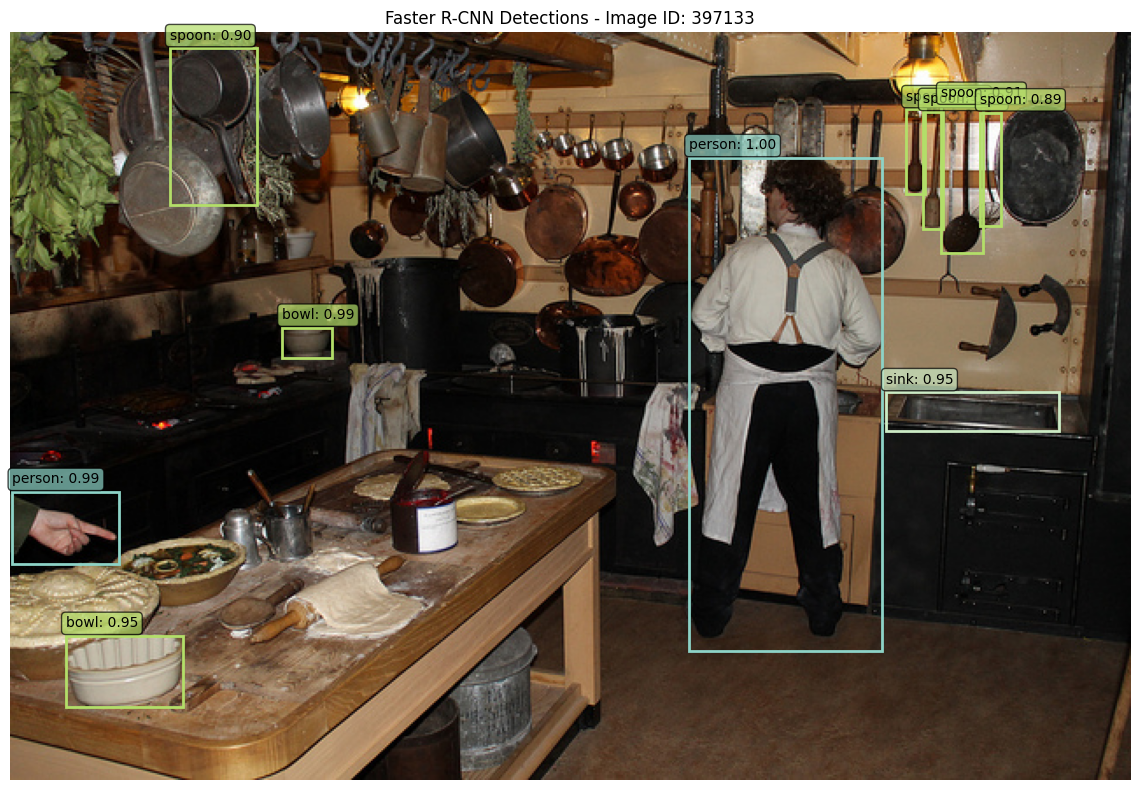


Image 2 (ID: 37777) - 17 detections


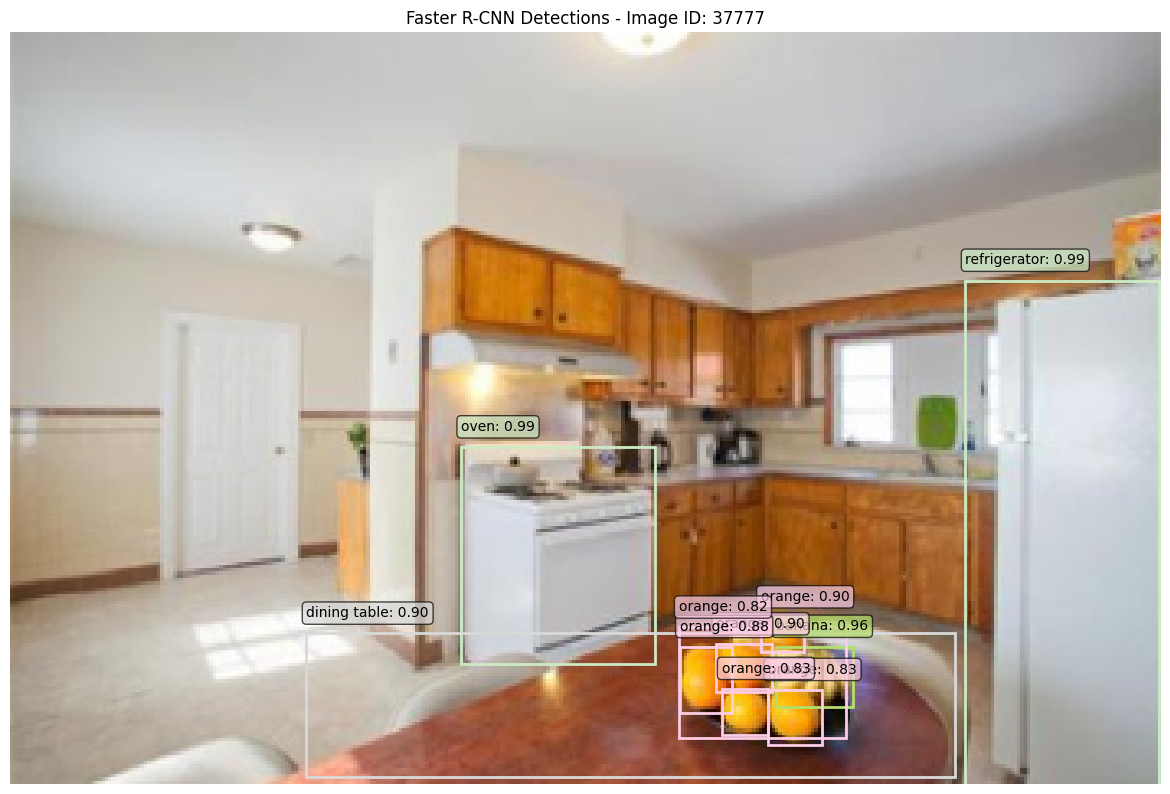


Image 3 (ID: 252219) - 11 detections


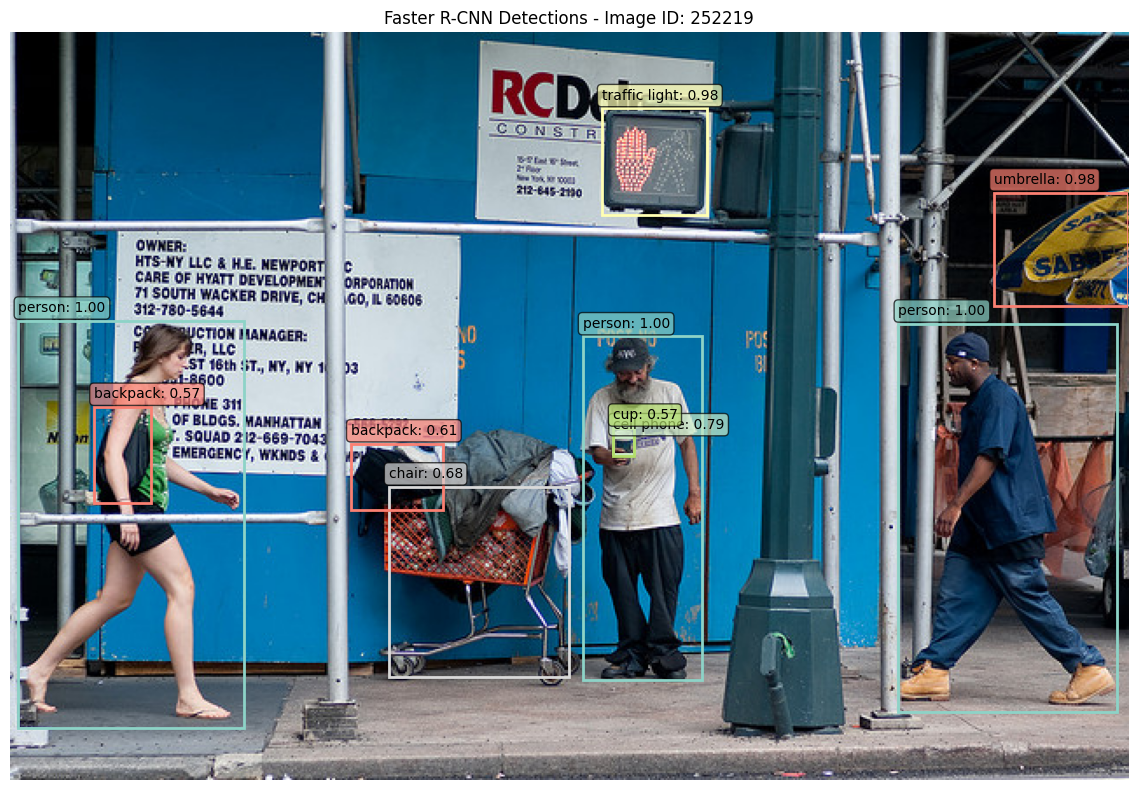


=== Faster R-CNN Evaluation Complete ===
All metrics and visualizations generated successfully!


In [12]:
# COCO Evaluation and Visualization

# Perform COCO evaluation if ground truth annotations are available
def evaluate_with_coco_metrics(results_file, annotation_file):
    """
    Evaluate detection results using COCO metrics
    
    Args:
        results_file: Path to JSON file with detection results
        annotation_file: Path to COCO ground truth annotations
    
    Returns:
        dict: COCO evaluation metrics
    """
    try:
        # Load COCO ground truth
        coco_gt = COCO(annotation_file)
        
        # Load detection results
        coco_dt = coco_gt.loadRes(results_file)
        
        # Create evaluator
        coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
        
        # Restrict evaluation to subset of images if we only processed a subset
        if USE_SUBSET:
            img_ids = list(coco_gt.imgs.keys())[:MAX_IMAGES]
            coco_eval.params.imgIds = img_ids
        
        # Run evaluation
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()
        
        # Extract metrics
        metrics = {
            'AP_all': coco_eval.stats[0],  # AP @ IoU=0.50:0.95
            'AP_50': coco_eval.stats[1],   # AP @ IoU=0.50
            'AP_75': coco_eval.stats[2],   # AP @ IoU=0.75
            'AP_small': coco_eval.stats[3], # AP for small objects
            'AP_medium': coco_eval.stats[4], # AP for medium objects
            'AP_large': coco_eval.stats[5], # AP for large objects
            'AR_1': coco_eval.stats[6],    # AR @ 1 detection per image
            'AR_10': coco_eval.stats[7],   # AR @ 10 detections per image
            'AR_100': coco_eval.stats[8],  # AR @ 100 detections per image
            'AR_small': coco_eval.stats[9], # AR for small objects
            'AR_medium': coco_eval.stats[10], # AR for medium objects
            'AR_large': coco_eval.stats[11]  # AR for large objects
        }
        
        return metrics
        
    except Exception as e:
        print(f"COCO evaluation failed: {e}")
        return None

# Try to perform COCO evaluation
print("\n=== COCO Evaluation Metrics ===")
annotation_file = "data/coco2017/annotations/instances_val2017.json"
if os.path.exists(annotation_file):
    try:
        coco_metrics = evaluate_with_coco_metrics(results_file, annotation_file)
        if coco_metrics:
            print("COCO Evaluation Results for Faster R-CNN:")
            print(f"Average Precision (AP) @ IoU=0.50:0.95: {coco_metrics['AP_all']:.3f}")
            print(f"Average Precision (AP) @ IoU=0.50: {coco_metrics['AP_50']:.3f}")
            print(f"Average Precision (AP) @ IoU=0.75: {coco_metrics['AP_75']:.3f}")
            print(f"Average Precision (AP) for small objects: {coco_metrics['AP_small']:.3f}")
            print(f"Average Precision (AP) for medium objects: {coco_metrics['AP_medium']:.3f}")
            print(f"Average Precision (AP) for large objects: {coco_metrics['AP_large']:.3f}")
            print(f"Average Recall (AR) @ 100 detections: {coco_metrics['AR_100']:.3f}")
            
            # Add COCO metrics to stored results
            faster_rcnn_metrics.update(coco_metrics)
        else:
            print("COCO evaluation could not be completed")
    except Exception as e:
        print(f"Error during COCO evaluation: {e}")
else:
    print(f"Ground truth annotations not found at: {annotation_file}")
    print("Skipping COCO evaluation")

# Visualize sample detections
def visualize_detections(image_tensor, detections, image_id, max_detections=10):
    """
    Visualize detection results on an image
    
    Args:
        image_tensor: Input image tensor [C, H, W]
        detections: Detection results from model
        image_id: Image ID for title
        max_detections: Maximum number of detections to show
    """
    # Convert tensor to numpy array for visualization
    if isinstance(image_tensor, torch.Tensor):
        # Handle tensor format [C, H, W] -> [H, W, C]
        if image_tensor.dim() == 4:
            image_tensor = image_tensor.squeeze(0)
        
        image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
        
        # Ensure values are in [0, 1] range
        if image_np.max() <= 1.0:
            image_np = (image_np * 255).astype(np.uint8)
        else:
            image_np = image_np.astype(np.uint8)
    else:
        image_np = image_tensor
    
    # Create figure
    plt.figure(figsize=(12, 8))
    plt.imshow(image_np)
    plt.axis('off')
    plt.title(f'Faster R-CNN Detections - Image ID: {image_id}')
    
    # Draw bounding boxes
    boxes = detections['boxes'][:max_detections]
    labels = detections['labels'][:max_detections]
    scores = detections['scores'][:max_detections]
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(COCO_CLASSES)))
    
    for i, (box, label, score) in enumerate(zip(boxes, labels, scores)):
        x1, y1, x2, y2 = box.numpy()
        width = x2 - x1
        height = y2 - y1
        
        # Get class name and color
        class_name = COCO_CLASSES[label] if label < len(COCO_CLASSES) else f'Class_{label}'
        color = colors[label % len(colors)]
        
        # Draw bounding box
        rect = plt.Rectangle((x1, y1), width, height, 
                           linewidth=2, edgecolor=color, facecolor='none')
        plt.gca().add_patch(rect)
        
        # Add label with confidence score
        plt.text(x1, y1 - 5, f'{class_name}: {score:.2f}', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7),
                fontsize=10, color='black')
    
    plt.tight_layout()
    plt.show()

# Show sample detections from the first few images
print(f"\n=== Sample Detection Visualizations ===")
print("Showing detection results from first 3 images...")

# Get a few sample images for visualization
sample_indices = [0, 1, 2]  # First 3 images
for idx in sample_indices:
    try:
        # Get image and target
        image, target = dataset_subset[idx]
        image_id = target['image_id'].item()
        
        # Perform inference for visualization
        with torch.no_grad():
            detections = faster_rcnn_inference(faster_rcnn, image, CONFIDENCE_THRESHOLD)
        
        # Visualize
        print(f"\nImage {idx + 1} (ID: {image_id}) - {len(detections['boxes'])} detections")
        visualize_detections(image, detections, image_id)
        
    except Exception as e:
        print(f"Error visualizing image {idx}: {e}")

print(f"\n=== Faster R-CNN Evaluation Complete ===")
print(f"All metrics and visualizations generated successfully!")

In [13]:
# Comprehensive Faster R-CNN Performance Summary

import pandas as pd

print("=" * 60)
print("           FASTER R-CNN PERFORMANCE SUMMARY")
print("=" * 60)

# Create a comprehensive metrics dataframe for better visualization
metrics_data = {
    'Metric': [
        'Model Name',
        'Dataset Split',
        'Images Processed',
        'Confidence Threshold',
        'Device Used',
        '',
        '--- TIMING METRICS ---',
        'Total Inference Time (s)',
        'Average Time per Image (s)',
        'Standard Deviation (s)',
        'Fastest Inference (s)',
        'Slowest Inference (s)',
        'Inference Speed (images/s)',
        '',
        '--- MEMORY METRICS ---',
        'Average CPU Memory (MB)',
        'Peak CPU Memory (MB)',
        'Avg Memory Increase per Image (MB)',
        'Average GPU Memory (MB)',
        'Peak GPU Memory (MB)',
        '',
        '--- DETECTION METRICS ---',
        'Total Detections',
        'Average Detections per Image',
        'Average Confidence Score',
        'Confidence Score Std Dev',
        'Min Confidence Score',
        'Max Confidence Score',
        '',
        '--- COCO EVALUATION ---',
        'Average Precision (AP) @ IoU=0.5:0.95',
        'Average Precision (AP) @ IoU=0.5',
        'Average Precision (AP) @ IoU=0.75',
        'AP for Small Objects',
        'AP for Medium Objects', 
        'AP for Large Objects',
        'Average Recall (AR) @ 100 detections'
    ],
    'Value': [
        'Faster R-CNN (ResNet-50 FPN)',
        'COCO 2017 Validation (subset)',
        f"{faster_rcnn_metrics['total_images']}",
        f"{faster_rcnn_metrics['confidence_threshold']}",
        str(device),
        '',
        '',
        f"{faster_rcnn_metrics['total_inference_time']:.2f}",
        f"{faster_rcnn_metrics['avg_time_per_image']:.3f}",
        f"{faster_rcnn_metrics['std_time_per_image']:.3f}",
        f"{np.min(inference_times):.3f}",
        f"{np.max(inference_times):.3f}",
        f"{faster_rcnn_metrics['images_per_second']:.2f}",
        '',
        '',
        f"{faster_rcnn_metrics['avg_cpu_memory']:.2f}",
        f"{faster_rcnn_metrics['peak_cpu_memory']:.2f}",
        f"{np.mean(np.array(memory_usage_after) - np.array(memory_usage_before)):.2f}",
        f"{faster_rcnn_metrics['avg_gpu_memory']:.2f}" if torch.cuda.is_available() else "N/A (CPU)",
        f"{faster_rcnn_metrics['peak_gpu_memory']:.2f}" if torch.cuda.is_available() else "N/A (CPU)",
        '',
        '',
        f"{faster_rcnn_metrics['total_detections']}",
        f"{faster_rcnn_metrics['avg_detections_per_image']:.2f}",
        f"{faster_rcnn_metrics['avg_confidence']:.3f}",
        f"{np.std(scores_all):.3f}" if scores_all else "N/A",
        f"{np.min(scores_all):.3f}" if scores_all else "N/A",
        f"{np.max(scores_all):.3f}" if scores_all else "N/A",
        '',
        '',
        f"{faster_rcnn_metrics.get('AP_all', 'N/A'):.3f}" if 'AP_all' in faster_rcnn_metrics else "Not Available",
        f"{faster_rcnn_metrics.get('AP_50', 'N/A'):.3f}" if 'AP_50' in faster_rcnn_metrics else "Not Available",
        f"{faster_rcnn_metrics.get('AP_75', 'N/A'):.3f}" if 'AP_75' in faster_rcnn_metrics else "Not Available",
        f"{faster_rcnn_metrics.get('AP_small', 'N/A'):.3f}" if 'AP_small' in faster_rcnn_metrics else "Not Available",
        f"{faster_rcnn_metrics.get('AP_medium', 'N/A'):.3f}" if 'AP_medium' in faster_rcnn_metrics else "Not Available",
        f"{faster_rcnn_metrics.get('AP_large', 'N/A'):.3f}" if 'AP_large' in faster_rcnn_metrics else "Not Available",
        f"{faster_rcnn_metrics.get('AR_100', 'N/A'):.3f}" if 'AR_100' in faster_rcnn_metrics else "Not Available"
    ]
}

# Create and display the summary table
summary_df = pd.DataFrame(metrics_data)

# Print the summary in a nice format
for i, row in summary_df.iterrows():
    if row['Metric'] == '':
        print()
    elif row['Metric'].startswith('---'):
        print(f"\n{row['Metric']}")
    else:
        print(f"{row['Metric']:<40} : {row['Value']}")

print("\n" + "=" * 60)

# Save metrics to file for later comparison
metrics_file = "logs/faster_rcnn_metrics_summary.json"
with open(metrics_file, 'w') as f:
    json.dump(faster_rcnn_metrics, f, indent=2)

print(f"Detailed metrics saved to: {metrics_file}")

# Performance insights
print(f"\n{'PERFORMANCE INSIGHTS':<60}")
print("=" * 60)

print(f"• Inference Speed: {faster_rcnn_metrics['images_per_second']:.2f} images/second")
if faster_rcnn_metrics['images_per_second'] >= 10:
    print("  → EXCELLENT: Real-time capable (>10 fps)")
elif faster_rcnn_metrics['images_per_second'] >= 5:
    print("  → GOOD: Near real-time performance (5-10 fps)")
elif faster_rcnn_metrics['images_per_second'] >= 1:
    print("  → MODERATE: Batch processing suitable (1-5 fps)")
else:
    print("  → SLOW: Offline processing only (<1 fps)")

print(f"\n• Average Detections: {faster_rcnn_metrics['avg_detections_per_image']:.1f} objects per image")
if faster_rcnn_metrics['avg_detections_per_image'] >= 10:
    print("  → HIGH: Good at detecting multiple objects")
elif faster_rcnn_metrics['avg_detections_per_image'] >= 5:
    print("  → MODERATE: Reasonable detection density")
else:
    print("  → LOW: Conservative detection approach")

print(f"\n• Confidence Scores: {faster_rcnn_metrics['avg_confidence']:.3f} average")
if faster_rcnn_metrics['avg_confidence'] >= 0.8:
    print("  → HIGH: Very confident predictions")
elif faster_rcnn_metrics['avg_confidence'] >= 0.6:
    print("  → MODERATE: Reasonably confident predictions")
else:
    print("  → LOW: Less confident predictions")

if 'AP_50' in faster_rcnn_metrics:
    print(f"\n• COCO AP @ IoU=0.5: {faster_rcnn_metrics['AP_50']:.3f}")
    if faster_rcnn_metrics['AP_50'] >= 0.5:
        print("  → EXCELLENT: High detection accuracy")
    elif faster_rcnn_metrics['AP_50'] >= 0.3:
        print("  → GOOD: Solid detection performance")
    elif faster_rcnn_metrics['AP_50'] >= 0.1:
        print("  → MODERATE: Acceptable for some applications")
    else:
        print("  → LOW: May need improvement")

print(f"\n• Memory Efficiency:")
avg_mem_per_image = np.mean(np.array(memory_usage_after) - np.array(memory_usage_before))
print(f"  Memory usage per image: {avg_mem_per_image:.1f} MB")
if avg_mem_per_image <= 10:
    print("  → EXCELLENT: Very memory efficient")
elif avg_mem_per_image <= 50:
    print("  → GOOD: Reasonable memory usage")
elif avg_mem_per_image <= 100:
    print("  → MODERATE: Noticeable memory usage")
else:
    print("  → HIGH: Significant memory requirements")

print(f"\n{'RECOMMENDATIONS FOR FASTER R-CNN':<60}")
print("=" * 60)
print("✓ Suitable for: High-accuracy object detection applications")
print("✓ Best for: Scenarios where accuracy is more important than speed")
print("✓ Consider for: Research, quality control, detailed analysis")
print("• Optimization tips:")
print("  - Use GPU acceleration for better performance")
print("  - Adjust confidence threshold based on application needs")
print("  - Consider model quantization for faster inference")
print("  - Batch processing for multiple images")

print(f"\n✅ Faster R-CNN evaluation completed successfully!")
print(f"📊 Ready for comparison with DETR, DINO, and Grounding DINO")

           FASTER R-CNN PERFORMANCE SUMMARY
Model Name                               : Faster R-CNN (ResNet-50 FPN)
Dataset Split                            : COCO 2017 Validation (subset)
Images Processed                         : 100
Confidence Threshold                     : 0.5
Device Used                              : cpu


--- TIMING METRICS ---
Total Inference Time (s)                 : 72.42
Average Time per Image (s)               : 0.718
Standard Deviation (s)                   : 0.059
Fastest Inference (s)                    : 0.560
Slowest Inference (s)                    : 0.869
Inference Speed (images/s)               : 1.38


--- MEMORY METRICS ---
Average CPU Memory (MB)                  : 3527.67
Peak CPU Memory (MB)                     : 3625.67
Avg Memory Increase per Image (MB)       : 25.47
Average GPU Memory (MB)                  : N/A (CPU)
Peak GPU Memory (MB)                     : N/A (CPU)


--- DETECTION METRICS ---
Total Detections                         :

## **DinoV3**

### Import DinoV3 Model

In [ ]:
# Load model directly
# Documentation: https://huggingface.co/facebook/dinov3-vit7b16-pretrain-lvd1689m
from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vit7b16-pretrain-lvd1689m")
model = AutoModel.from_pretrained("facebook/dinov3-vit7b16-pretrain-lvd1689m")

### Perform Inference and Measure Performance Metrics for DinoV3

## **DETR**

### Import DETR Model

In [ ]:
# Load model directly
# Documentation: https://huggingface.co/facebook/detr-resnet-50
from transformers import AutoImageProcessor, AutoModelForObjectDetection

processor = AutoImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = AutoModelForObjectDetection.from_pretrained("facebook/detr-resnet-50")

### Perform Inference and Measure Performance Metrics for DETR

## **Grounding-DINO**

### Import Grounding-DINO Model

In [ ]:
# Load model directly
# Documentation: https://huggingface.co/IDEA-Research/grounding-dino-base
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-base")
model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-base")

### Perform Inference and Measure Performance Metrics for Grounding-DINO